In [1]:
#Import libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from xgboost import XGBRegressor

In [4]:
csv = '../lifespan_merged_datasets/mergedworms_companyDrug.csv'# Read the CSV file
data = pd.read_csv(csv)

np.random.seed(42)

## Lifespan Estimation

In [5]:
def predict_lifespan(data, model_select="linear", test_size=0.2, random_state=42):
    """
    Predict the lifespan of worms based on behavioral data.

    Args:
        df: DataFrame containing the dataset.
        model_select: Choice of regression model ('linear', 'random_forest', 'xgboost').
        test_size: Fraction of data to use as test set.
        random_state: Seed for reproducibility.

    Returns:
        None (prints evaluation metrics and feature importances for tree-based models).
    """
    df = data.copy()
    # csv = 'mergedworms.csv'# Read the CSV file
    # df = pd.read_csv(csv)


    # Preprocess lifespan (convert from hours to days)
    df['lifespan'] = df['lifespan'] / 24

    # Extract features (X), target (y), and groups (worm_id)
    # X = df.drop(columns=['id', 'worm_id', 'lifespan', 'average_distance_per_frame', 'maximal_distance_traveled', 'average_acceleration'])
    X = df.drop(columns = ['lifespan', 'worm_id']) #id
    y = df['lifespan']
    groups = df['worm_id']

    # Split the dataset into training and testing based on worm_id grouping
    gkf = GroupKFold(n_splits=int(1 / test_size))
    train_idx, test_idx = next(gkf.split(X, y, groups))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # sample imputing (NEED TO IMPROVE) -- ONLY TEMPORARY
    if np.isnan(X_train).any().any() or np.isnan(X_test).any().any():
        # Impute missing values with the median
        imputer = SimpleImputer(strategy='median')
        X_train = imputer.fit_transform(X_train)
        X_test = imputer.fit_transform(X_test)

    # Initialize the model
    if model_select == "linear":
        model = LinearRegression()
    elif model_select == "random_forest":
        model = RandomForestRegressor(random_state=random_state)
    elif model_select == "xgboost":
        model = XGBRegressor(random_state=random_state, n_estimators=100, learning_rate=0.05)
    else:
        raise Exception("Invalid model selected. Options are 'linear', 'random_forest', 'xgboost'.")

    # Scale features for linear models
    if model_select == "linear":
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    # Train the model
    model.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"R^2 Score: {r2:.2f}")

    # Feature importance for tree-based models
    if model_select in ["random_forest", "xgboost"]:
        importances = model.feature_importances_
        feature_importances = sorted(zip(X.columns, importances), key=lambda x: -x[1])
        print("\nFeature Importances:")
        for feature, importance in feature_importances:
            print(f"{feature}: {importance:.4f}")

    import matplotlib.pyplot as plt
    plt.scatter(y_test, y_pred, alpha=0.7)
    plt.xlabel("Actual Lifespan (days)")
    plt.ylabel("Predicted Lifespan (days)")
    plt.title("Predicted vs. Actual Lifespan")
    plt.show()

    print("y_pred max min", y_pred.max(), y_pred.min())
    print("y_test max min", y_test.max(), y_test.min())

    return model, mse, r2

Mean Squared Error: 2.04
R^2 Score: 0.46


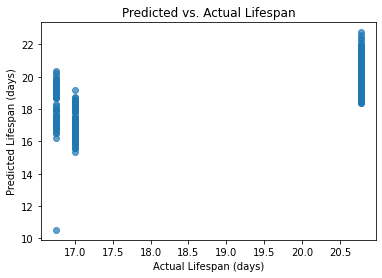

y_pred max min 22.752320457356742 10.523146246594855
y_test max min 20.770671296296296 16.754652777777782


In [6]:
model, mse, r2 = predict_lifespan(data)

Mean Squared Error: 2.37
R^2 Score: 0.37

Feature Importances:
maximal_distance_traveled: 0.2078
total_distance_traveled: 0.1935
drugged: 0.1543
time_elapsed_(hours): 0.0826
distance_traveled_bin: 0.0759
roaming_fraction: 0.0617
group: 0.0428
average_angular_speed: 0.0340
std/mean: 0.0290
average_acceleration: 0.0268
average_change_in_pixels: 0.0252
average_speed: 0.0237
std_speed: 0.0233
average_distance_per_frame: 0.0195


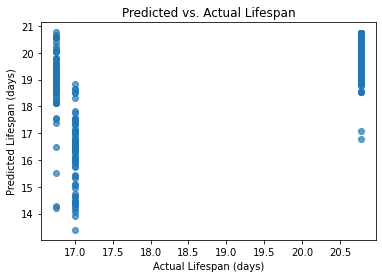

y_pred max min 20.76900555555557 13.387097222222213
y_test max min 20.770671296296296 16.754652777777782


In [7]:
model, mse, r2 = predict_lifespan(data, model_select="random_forest")

Mean Squared Error: 2.17
R^2 Score: 0.43

Feature Importances:
drugged: 0.2744
maximal_distance_traveled: 0.2097
time_elapsed_(hours): 0.1583
distance_traveled_bin: 0.0914
roaming_fraction: 0.0527
group: 0.0406
std/mean: 0.0332
std_speed: 0.0315
average_speed: 0.0304
average_change_in_pixels: 0.0295
average_acceleration: 0.0262
average_angular_speed: 0.0219
average_distance_per_frame: 0.0000
total_distance_traveled: 0.0000


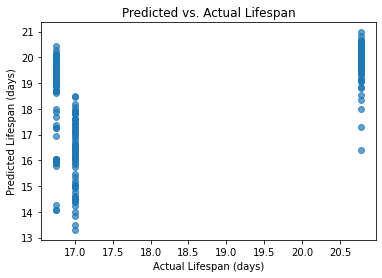

y_pred max min 20.974995 13.297626
y_test max min 20.770671296296296 16.754652777777782


In [8]:
model, mse, r2 = predict_lifespan(data, model_select="xgboost")

In [19]:
csv = '../lifespan_merged_datasets/mergedworms_companyDrug.csv'# Read the CSV file
data = pd.read_csv(csv)

aggregated_data = data.groupby("worm_id").agg({
    "worm_id": "first",
    "group": "first",  # Assuming group is constant per worm
    "average_speed": ["mean", "median", "min", "max"],
    "maximal_distance_traveled": "max",  # Keep max as it may capture peaks
    "average_change_in_pixels": ["mean", "std", "median", "min", "max"],
    "average_angular_speed": ["mean", "std", "min", "max"],
    "distance_traveled_bin": ["std"],
    "time_elapsed_(hours)": "max",  # Keep max as it's likely cumulative
    "std_speed": "mean",  # Capture average variability
    "std/mean": "mean",  # Keep mean of std/mean as a ratio metric
    "roaming_fraction": "mean",  # Capture average roaming behavior
    "lifespan": "first",  # Lifespan is constant per worm
    "drugged": "first"  # Assuming drugged is constant per worm
})
aggregated_data.columns = ["_".join(col).strip() for col in aggregated_data.columns]
aggregated_data.rename(columns={"lifespan_first": "lifespan", "worm_id_first": "worm_id"}, inplace=True)

In [14]:
# aggregated_data.columns
aggregated_data['lifespan']

worm_id
1     354.497222
2     498.496111
3     498.496111
4     498.445000
5     498.496111
6     426.496667
7     498.167222
8     498.496111
9     336.460000
10    498.496111
11    468.167222
12    402.111667
37    498.496111
38    288.463889
39    324.222778
40    426.496667
41    462.389444
42    450.000556
43    414.222778
44    396.005000
45    420.278333
46    408.167222
47    450.000556
48    312.389444
Name: lifespan, dtype: float64

In [15]:
# Check for high correlation and avoid duplicates
# Iterate through the upper triangle of the correlation matrix (to avoid duplicates)
correlation_matrix = aggregated_data.corr()

# Threshold for high correlation
threshold = 0.75

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):  # Upper triangle
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            correlation_value = correlation_matrix.iloc[i, j]
            print(f"Highly correlated: {col1} and {col2} with correlation {correlation_value:.2f}")

Highly correlated: worm_id and drugged_first with correlation -0.98
Highly correlated: average_speed_mean and average_speed_median with correlation 0.78
Highly correlated: average_speed_mean and maximal_distance_traveled_max with correlation 0.87
Highly correlated: average_speed_mean and distance_traveled_bin_std with correlation 0.80
Highly correlated: average_speed_mean and std_speed_mean with correlation 0.79
Highly correlated: average_speed_mean and lifespan with correlation -0.83
Highly correlated: average_speed_median and lifespan with correlation -0.81
Highly correlated: average_speed_max and distance_traveled_bin_std with correlation 0.97
Highly correlated: maximal_distance_traveled_max and distance_traveled_bin_std with correlation 0.79
Highly correlated: average_change_in_pixels_mean and average_change_in_pixels_max with correlation 0.91
Highly correlated: average_change_in_pixels_std and average_change_in_pixels_max with correlation 0.89
Highly correlated: average_angular_sp

In [16]:
model, mse, r2 = predict_lifespan(aggregated_data, model_select="xgboost")

KeyError: "['id'] not found in axis"

In [28]:
csv2 = 'mergedworms_final.csv'# Read the CSV file
data2 = pd.read_csv(csv2)



In [29]:
data2.isna().sum()

Unnamed: 0                    0
group                         0
average_speed                 0
average_distance_per_frame    0
maximal_distance_traveled     0
average_change_in_pixels      0
average_angular_speed         0
distance_travaled             0
distance_travaled.1           0
average_change_speed          0
time_elapsed_(hours)          0
std_speed                     4
std/mean                      4
roaming_fraction              0
lifespan                      0
drugged                       0
worm_id                       0
dtype: int64

In [25]:
data2.shape

(312, 17)